# Multi-Period Replenishment Optimization

This notebook formulates and solves a seven-day linear replenishment model
using the fixed demand forecasts produced in `02_demand_analysis.ipynb`.
Scenario parameters not directly observed in FreshRetailNet-LT are explicitly
separated from data-derived inputs.

## 1. Optimization Inputs

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog

pd.set_option("display.max_columns", None)

ROOT = Path("..").resolve()

FORECAST_PATH = (
    ROOT
    / "data"
    / "processed"
    / "demand_forecast.csv"
)

RECOVERED_PATH = (
    ROOT
    / "data"
    / "processed"
    / "recovered_demand.csv"
)

forecast = pd.read_csv(
    FORECAST_PATH,
    parse_dates=["dt"]
)

history = pd.read_csv(
    RECOVERED_PATH,
    parse_dates=["dt"]
)

print(forecast.shape)
print(history.shape)

(175, 4)
(16904, 8)


In [2]:
PRODUCTS = sorted(
    forecast["product_id"].unique()
)

DATES = sorted(
    forecast["dt"].unique()
)

demand_matrix = (
    forecast
    .pivot(
        index="product_id",
        columns="dt",
        values="forecast_demand"
    )
    .reindex(
        index=PRODUCTS,
        columns=DATES
    )
)

demand_matrix

dt,2025-07-14,2025-07-15,2025-07-16,2025-07-17,2025-07-18,2025-07-19,2025-07-20
product_id,,,,,,,
59,4.130437,3.964990,3.985945,3.389414,3.925175,4.801938,5.015521
99,4.353371,3.693699,4.637333,2.940081,3.448191,5.368837,5.360401
102,1.659065,1.365388,1.475000,1.177500,1.185180,1.472183,2.054460
104,1.168026,1.429639,0.938216,1.964833,1.937971,2.131750,2.186125
108,3.710252,3.232621,2.762537,2.564753,2.809496,3.555017,3.062246
128,1.601795,1.701394,1.390317,1.272064,1.630630,1.466585,1.475000
160,1.917269,1.924257,1.175053,1.178921,1.671519,2.257408,1.500000
190,2.960563,2.615026,2.123666,2.325000,2.250000,2.371264,2.828333
192,3.741541,2.873970,2.991282,3.075000,3.274150,4.331340,3.686828


In [3]:
optimization_input_check = pd.DataFrame({
    "n_products": [len(PRODUCTS)],
    "n_days": [len(DATES)],
    "missing_demand": [
        demand_matrix.isna().sum().sum()
    ],
    "negative_demand": [
        (demand_matrix < 0).sum().sum()
    ],
    "total_weekly_demand": [
        demand_matrix.to_numpy().sum()
    ],
})

optimization_input_check

,n_products,n_days,missing_demand,negative_demand,total_weekly_demand
0,25,7,0,0,408.656289


## 2. Scenario Calibration

In [4]:
historical_daily_coverage = (
    history
    .groupby("dt", as_index=False)
    .agg(
        n_products=(
            "product_id",
            "nunique"
        ),
        total_recovered_demand=(
            "recovered_demand",
            "sum"
        )
    )
)

historical_daily_coverage[
    "n_products"
].value_counts().sort_index()

n_products
14     12
15     75
16     28
17     23
18      3
19      4
20     13
21    105
22     20
23    144
24    150
25    193
Name: count, dtype: int64

In [5]:
full_portfolio_history = (
    historical_daily_coverage[
        historical_daily_coverage[
            "n_products"
        ] == len(PRODUCTS)
    ]
    .copy()
)

print(
    "Full-portfolio historical days:",
    len(full_portfolio_history)
)

print(
    "First full-portfolio date:",
    full_portfolio_history["dt"].min()
)

print(
    "Last full-portfolio date:",
    full_portfolio_history["dt"].max()
)

Full-portfolio historical days: 193
First full-portfolio date: 2024-07-11 00:00:00
Last full-portfolio date: 2025-07-13 00:00:00


In [6]:
full_portfolio_capacity_quantiles = (
    full_portfolio_history[
        "total_recovered_demand"
    ]
    .quantile(
        [0.50, 0.60, 0.75, 0.90, 0.95]
    )
    .rename("capacity")
    .reset_index()
    .rename(
        columns={"index": "quantile"}
    )
)

full_portfolio_capacity_quantiles

,quantile,capacity
0,0.50,53.367548
1,0.60,56.867736
2,0.75,62.850277
3,0.90,70.481525
4,0.95,75.560762


In [7]:
full_portfolio_history[
    "total_recovered_demand"
].describe(
    percentiles=[
        0.50,
        0.60,
        0.75,
        0.90,
        0.95,
    ]
)

count    193.000000
mean      53.653699
std       13.405875
min       10.831894
50%       53.367548
60%       56.867736
75%       62.850277
90%       70.481525
95%       75.560762
max       95.376555
Name: total_recovered_demand, dtype: float64

In [8]:
forecast_daily_total = (
    forecast
    .groupby("dt", as_index=False)
    .agg(
        forecast_demand=(
            "forecast_demand",
            "sum"
        )
    )
)

forecast_daily_total

,dt,forecast_demand
0,2025-07-14,59.868756
1,2025-07-15,56.968021
2,2025-07-16,51.947074
3,2025-07-17,51.627789
4,2025-07-18,56.357111
5,2025-07-19,66.093710
6,2025-07-20,65.793829


## 3. Base Planning Scenario

The primary optimization experiment uses a daily replenishment capacity of
56.87 normalized planning units, corresponding to the 60th percentile of
historical recovered portfolio demand on days with complete 25-product
coverage.

The base carryover factor is set to 0.80 and initial usable inventory is set
to zero. These values are planning assumptions rather than estimates of the
retailer's actual inventory system. Capacity and carryover assumptions are
varied systematically in subsequent sensitivity analysis.

In [9]:
capacity_by_quantile = (
    full_portfolio_capacity_quantiles
    .set_index("quantile")[
        "capacity"
    ]
)

CAPACITY_SCENARIOS = {
    "tight": float(
        capacity_by_quantile.loc[0.50]
    ),
    "base": float(
        capacity_by_quantile.loc[0.60]
    ),
    "adequate": float(
        capacity_by_quantile.loc[0.75]
    ),
    "relaxed": float(
        capacity_by_quantile.loc[0.90]
    ),
}

CARRYOVER_SCENARIOS = {
    "high_perishability": 0.60,
    "base": 0.80,
    "no_decay": 1.00,
}

BASE_CAPACITY = (
    CAPACITY_SCENARIOS["base"]
)

BASE_ALPHA = (
    CARRYOVER_SCENARIOS["base"]
)

INITIAL_INVENTORY = 0.0

scenario_summary = pd.DataFrame({
    "parameter": [
        "daily_capacity",
        "carryover_factor",
        "initial_inventory_per_product",
    ],
    "base_value": [
        BASE_CAPACITY,
        BASE_ALPHA,
        INITIAL_INVENTORY,
    ],
})

scenario_summary

,parameter,base_value
0,daily_capacity,56.867736
1,carryover_factor,0.800000
2,initial_inventory_per_product,0.000000


## 4. Stage 1: Maximum Demand Fulfillment

The first optimization stage maximizes total fulfilled forecast demand subject
to inventory-flow, demand, and shared daily replenishment-capacity
constraints.

In [10]:
N_PRODUCTS = len(PRODUCTS)
N_DAYS = len(DATES)
N_PRODUCT_DAYS = N_PRODUCTS * N_DAYS

demand = demand_matrix.to_numpy(
    dtype=float
)

def flat_index(i, t):
    return i * N_DAYS + t

In [11]:
stage1_objective = np.concatenate([
    np.zeros(N_PRODUCT_DAYS),
    -np.ones(N_PRODUCT_DAYS),
    np.zeros(N_PRODUCT_DAYS),
])

In [12]:
A_eq_rows = []
b_eq_values = []

for i in range(N_PRODUCTS):
    for t in range(N_DAYS):
        row = np.zeros(
            3 * N_PRODUCT_DAYS
        )

        x_index = flat_index(i, t)
        s_index = (
            N_PRODUCT_DAYS
            + flat_index(i, t)
        )
        inventory_index = (
            2 * N_PRODUCT_DAYS
            + flat_index(i, t)
        )

        row[inventory_index] = 1.0
        row[x_index] = -1.0
        row[s_index] = 1.0

        if t == 0:
            rhs = INITIAL_INVENTORY
        else:
            previous_inventory_index = (
                2 * N_PRODUCT_DAYS
                + flat_index(i, t - 1)
            )

            row[
                previous_inventory_index
            ] = -BASE_ALPHA

            rhs = 0.0

        A_eq_rows.append(row)
        b_eq_values.append(rhs)

A_eq = np.vstack(A_eq_rows)
b_eq = np.asarray(
    b_eq_values,
    dtype=float
)

print(A_eq.shape)
print(b_eq.shape)

(175, 525)
(175,)


In [13]:
A_ub_rows = []
b_ub_values = []

for t in range(N_DAYS):
    row = np.zeros(
        3 * N_PRODUCT_DAYS
    )

    for i in range(N_PRODUCTS):
        row[
            flat_index(i, t)
        ] = 1.0

    A_ub_rows.append(row)
    b_ub_values.append(
        BASE_CAPACITY
    )

A_ub = np.vstack(A_ub_rows)
b_ub = np.asarray(
    b_ub_values,
    dtype=float
)

print(A_ub.shape)
print(b_ub.shape)

(7, 525)
(7,)


In [14]:
bounds = []

for i in range(N_PRODUCTS):
    for t in range(N_DAYS):
        bounds.append(
            (0.0, None)
        )

for i in range(N_PRODUCTS):
    for t in range(N_DAYS):
        bounds.append(
            (
                0.0,
                demand[i, t]
            )
        )

for i in range(N_PRODUCTS):
    for t in range(N_DAYS):
        bounds.append(
            (0.0, None)
        )

In [15]:
stage1_result = linprog(
    c=stage1_objective,
    A_ub=A_ub,
    b_ub=b_ub,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method="highs",
)

print(
    "Success:",
    stage1_result.success
)

print(
    "Status:",
    stage1_result.status
)

print(
    "Message:",
    stage1_result.message
)

print(
    "Objective:",
    stage1_result.fun
)

Success: True
Status: 0
Message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Objective: -393.6843658639232


In [16]:
stage1_service = (
    -stage1_result.fun
)

stage1_fill_rate = (
    stage1_service
    / demand.sum()
)

print(
    "Maximum fulfilled demand:",
    stage1_service
)

print(
    "Total forecast demand:",
    demand.sum()
)

print(
    "Portfolio fill rate:",
    stage1_fill_rate
)

Maximum fulfilled demand: 393.6843658639232
Total forecast demand: 408.65628945136336
Portfolio fill rate: 0.9633630413285929


## 5. Stage 1 Solution Validation

The numerical solution is checked directly against the inventory-balance equations, daily replenishment-capacity constraints, demand bounds, nonnegativity conditions, and reconstructed objective value before proceeding to the lexicographic fairness stage.

In [17]:
stage1_solution = stage1_result.x

stage1_x = (
    stage1_solution[
        :N_PRODUCT_DAYS
    ]
    .reshape(
        N_PRODUCTS,
        N_DAYS
    )
)

stage1_s = (
    stage1_solution[
        N_PRODUCT_DAYS:
        2 * N_PRODUCT_DAYS
    ]
    .reshape(
        N_PRODUCTS,
        N_DAYS
    )
)

stage1_inventory = (
    stage1_solution[
        2 * N_PRODUCT_DAYS:
    ]
    .reshape(
        N_PRODUCTS,
        N_DAYS
    )
)

print(stage1_x.shape)
print(stage1_s.shape)
print(stage1_inventory.shape)

(25, 7)
(25, 7)
(25, 7)


In [18]:
equality_residual = (
    A_eq
    @ stage1_solution
    - b_eq
)

capacity_residual = (
    A_ub
    @ stage1_solution
    - b_ub
)

maximum_equality_residual = (
    np.max(
        np.abs(
            equality_residual
        )
    )
)

maximum_capacity_violation = max(
    0.0,
    float(
        np.max(
            capacity_residual
        )
    )
)

maximum_demand_violation = max(
    0.0,
    float(
        np.max(
            stage1_s
            - demand
        )
    )
)

minimum_variable_value = float(
    stage1_solution.min()
)

objective_reconstruction_error = abs(
    stage1_s.sum()
    - stage1_service
)

stage1_validation = pd.DataFrame({
    "check": [
        "max_inventory_balance_residual",
        "max_capacity_violation",
        "max_demand_violation",
        "minimum_variable_value",
        "objective_reconstruction_error",
    ],
    "value": [
        maximum_equality_residual,
        maximum_capacity_violation,
        maximum_demand_violation,
        minimum_variable_value,
        objective_reconstruction_error,
    ],
})

stage1_validation

,check,value
0,max_inventory_balance_residual,8.881784e-16
1,max_capacity_violation,2.131628e-14
2,max_demand_violation,0.000000e+00
3,minimum_variable_value,-0.000000e+00
4,objective_reconstruction_error,1.136868e-13


In [19]:
balance_residuals = []

for i in range(N_PRODUCTS):
    for t in range(N_DAYS):
        if t == 0:
            available_inventory = (
                INITIAL_INVENTORY
                + stage1_x[i, t]
            )
        else:
            available_inventory = (
                BASE_ALPHA
                * stage1_inventory[
                    i,
                    t - 1
                ]
                + stage1_x[i, t]
            )

        implied_ending_inventory = (
            available_inventory
            - stage1_s[i, t]
        )

        balance_residuals.append(
            stage1_inventory[i, t]
            - implied_ending_inventory
        )

manual_balance_check = pd.DataFrame({
    "max_absolute_balance_residual": [
        np.max(
            np.abs(
                balance_residuals
            )
        )
    ]
})

manual_balance_check

,max_absolute_balance_residual
0,4.440892e-16


In [20]:
stage1_daily_summary = pd.DataFrame({
    "dt": DATES,
    "forecast_demand": (
        demand.sum(axis=0)
    ),
    "replenishment": (
        stage1_x.sum(axis=0)
    ),
    "fulfilled_demand": (
        stage1_s.sum(axis=0)
    ),
    "ending_inventory": (
        stage1_inventory.sum(axis=0)
    ),
})

stage1_daily_summary[
    "unmet_demand"
] = (
    stage1_daily_summary[
        "forecast_demand"
    ]
    - stage1_daily_summary[
        "fulfilled_demand"
    ]
)

stage1_daily_summary[
    "capacity_slack"
] = (
    BASE_CAPACITY
    - stage1_daily_summary[
        "replenishment"
    ]
)

for column in [
    "unmet_demand",
    "capacity_slack",
]:
    stage1_daily_summary[column] = np.where(
        np.isclose(
            stage1_daily_summary[column],
            0.0,
            atol=1e-10,
        ),
        0.0,
        stage1_daily_summary[column],
    )

stage1_daily_summary[
    "fill_rate"
] = (
    stage1_daily_summary[
        "fulfilled_demand"
    ]
    / stage1_daily_summary[
        "forecast_demand"
    ]
)

stage1_daily_summary

,dt,forecast_demand,replenishment,fulfilled_demand,ending_inventory,unmet_demand,capacity_slack,fill_rate
0,2025-07-14,59.868756,56.867736,56.867736,0.000000,3.001019,0.0,0.949873
1,2025-07-15,56.968021,56.867736,56.867736,0.000000,0.100284,0.0,0.998240
2,2025-07-16,51.947074,56.867736,51.947074,4.920662,0.000000,0.0,1.000000
3,2025-07-17,51.627789,56.867736,51.627789,9.176477,0.000000,0.0,1.000000
4,2025-07-18,56.357111,56.867736,56.357111,7.851807,0.000000,0.0,1.000000
5,2025-07-19,66.093710,56.867736,63.149182,0.000000,2.944527,0.0,0.955449
6,2025-07-20,65.793829,56.867736,56.867736,0.000000,8.926093,0.0,0.864332


In [21]:
stage1_product_summary = pd.DataFrame({
    "product_id": PRODUCTS,
    "forecast_demand": (
        demand.sum(axis=1)
    ),
    "fulfilled_demand": (
        stage1_s.sum(axis=1)
    ),
})

stage1_product_summary[
    "unmet_demand"
] = (
    stage1_product_summary[
        "forecast_demand"
    ]
    - stage1_product_summary[
        "fulfilled_demand"
    ]
)

stage1_product_summary[
    "fill_rate"
] = (
    stage1_product_summary[
        "fulfilled_demand"
    ]
    / stage1_product_summary[
        "forecast_demand"
    ]
)

stage1_product_summary.sort_values(
    "fill_rate"
).head(10)

,product_id,forecast_demand,fulfilled_demand,unmet_demand,fill_rate
7,190,17.473853,14.545235,2.928617,0.832400
17,380,8.568429,7.187574,1.380854,0.838844
22,506,15.675131,13.456685,2.218445,0.858474
9,199,14.071599,12.104366,1.967233,0.860198
6,160,11.624429,10.124429,1.500000,0.870961
0,59,29.213419,26.212399,3.001019,0.897273
10,204,16.342155,15.092483,1.249672,0.923531
18,415,27.935933,27.377283,0.558650,0.980002
8,192,23.974111,23.806679,0.167432,0.993016
21,503,27.720317,27.720317,0.000000,1.000000


## 6. Stage 2: Max-Min Product Fairness

The second lexicographic stage preserves the maximum total demand fulfillment
identified in Stage 1 while maximizing the minimum weekly product-level fill
rate. This prevents the total-service objective from concentrating shortages
arbitrarily on a small subset of products.

In [22]:
STAGE2_N_VARIABLES = (
    3 * N_PRODUCT_DAYS + 1
)

Z_INDEX = STAGE2_N_VARIABLES - 1

stage2_objective = np.zeros(
    STAGE2_N_VARIABLES
)

stage2_objective[Z_INDEX] = -1.0

In [23]:
stage2_A_eq_inventory = np.column_stack([
    A_eq,
    np.zeros(A_eq.shape[0]),
])

In [24]:
service_row = np.zeros(
    STAGE2_N_VARIABLES
)

service_row[
    N_PRODUCT_DAYS:
    2 * N_PRODUCT_DAYS
] = 1.0

stage2_A_eq = np.vstack([
    stage2_A_eq_inventory,
    service_row,
])

stage2_b_eq = np.concatenate([
    b_eq,
    [stage1_service],
])

print(stage2_A_eq.shape)
print(stage2_b_eq.shape)

(176, 526)
(176,)


In [25]:
stage2_capacity_rows = np.column_stack([
    A_ub,
    np.zeros(A_ub.shape[0]),
])

In [26]:
product_weekly_demand = (
    demand.sum(axis=1)
)

fairness_rows = []

for i in range(N_PRODUCTS):
    row = np.zeros(
        STAGE2_N_VARIABLES
    )

    for t in range(N_DAYS):
        s_index = (
            N_PRODUCT_DAYS
            + flat_index(i, t)
        )

        row[s_index] = -1.0

    row[Z_INDEX] = (
        product_weekly_demand[i]
    )

    fairness_rows.append(row)

fairness_A_ub = np.vstack(
    fairness_rows
)

fairness_b_ub = np.zeros(
    N_PRODUCTS
)

stage2_A_ub = np.vstack([
    stage2_capacity_rows,
    fairness_A_ub,
])

stage2_b_ub = np.concatenate([
    b_ub,
    fairness_b_ub,
])

print(stage2_A_ub.shape)
print(stage2_b_ub.shape)

(32, 526)
(32,)


In [27]:
stage2_bounds = (
    bounds
    + [(0.0, 1.0)]
)

len(stage2_bounds)

526

In [28]:
stage2_result = linprog(
    c=stage2_objective,
    A_ub=stage2_A_ub,
    b_ub=stage2_b_ub,
    A_eq=stage2_A_eq,
    b_eq=stage2_b_eq,
    bounds=stage2_bounds,
    method="highs",
)

print(
    "Success:",
    stage2_result.success
)

print(
    "Status:",
    stage2_result.status
)

print(
    "Message:",
    stage2_result.message
)

print(
    "Minimum product fill rate:",
    -stage2_result.fun
)

Success: True
Status: 0
Message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Minimum product fill rate: 0.9633630413285926


In [29]:
stage2_solution = stage2_result.x

stage2_x = (
    stage2_solution[
        :N_PRODUCT_DAYS
    ]
    .reshape(
        N_PRODUCTS,
        N_DAYS
    )
)

stage2_s = (
    stage2_solution[
        N_PRODUCT_DAYS:
        2 * N_PRODUCT_DAYS
    ]
    .reshape(
        N_PRODUCTS,
        N_DAYS
    )
)

stage2_inventory = (
    stage2_solution[
        2 * N_PRODUCT_DAYS:
        3 * N_PRODUCT_DAYS
    ]
    .reshape(
        N_PRODUCTS,
        N_DAYS
    )
)

stage2_z = float(
    stage2_solution[Z_INDEX]
)

stage2_service = (
    stage2_s.sum()
)

print(
    "Stage 1 service:",
    stage1_service
)

print(
    "Stage 2 service:",
    stage2_service
)

print(
    "Minimum fill rate:",
    stage2_z
)

Stage 1 service: 393.6843658639232
Stage 2 service: 393.6843658639231
Minimum fill rate: 0.9633630413285926


In [30]:
stage2_product_summary = pd.DataFrame({
    "product_id": PRODUCTS,
    "forecast_demand": (
        demand.sum(axis=1)
    ),
    "fulfilled_demand": (
        stage2_s.sum(axis=1)
    ),
})

stage2_product_summary[
    "unmet_demand"
] = (
    stage2_product_summary[
        "forecast_demand"
    ]
    - stage2_product_summary[
        "fulfilled_demand"
    ]
)

stage2_product_summary[
    "fill_rate"
] = (
    stage2_product_summary[
        "fulfilled_demand"
    ]
    / stage2_product_summary[
        "forecast_demand"
    ]
)

stage2_product_summary.sort_values(
    "fill_rate"
).head(10)

,product_id,forecast_demand,fulfilled_demand,unmet_demand,fill_rate
6,160,11.624429,11.198545,0.425884,0.963363
2,102,10.388776,10.008163,0.380613,0.963363
3,104,11.756560,11.325835,0.430725,0.963363
21,503,27.720317,26.704729,1.015588,0.963363
20,453,8.777691,8.456104,0.321588,0.963363
23,510,11.524676,11.102447,0.422229,0.963363
13,277,25.496691,24.562570,0.934121,0.963363
0,59,29.213419,28.143128,1.070291,0.963363
22,506,15.675131,15.100842,0.574289,0.963363
19,434,11.509289,11.087624,0.421665,0.963363


In [31]:
fairness_comparison = pd.DataFrame({
    "metric": [
        "total_service",
        "portfolio_fill_rate",
        "minimum_product_fill_rate",
        "maximum_product_fill_rate",
        "product_fill_rate_std",
    ],
    "stage1": [
        stage1_s.sum(),
        stage1_s.sum() / demand.sum(),
        stage1_product_summary[
            "fill_rate"
        ].min(),
        stage1_product_summary[
            "fill_rate"
        ].max(),
        stage1_product_summary[
            "fill_rate"
        ].std(),
    ],
    "stage2": [
        stage2_s.sum(),
        stage2_s.sum() / demand.sum(),
        stage2_product_summary[
            "fill_rate"
        ].min(),
        stage2_product_summary[
            "fill_rate"
        ].max(),
        stage2_product_summary[
            "fill_rate"
        ].std(),
    ],
})

fairness_comparison

,metric,stage1,stage2
0,total_service,393.684366,3.936844e+02
1,portfolio_fill_rate,0.963363,9.633630e-01
2,minimum_product_fill_rate,0.832400,9.633630e-01
3,maximum_product_fill_rate,1.000000,9.633630e-01
4,product_fill_rate_std,0.061709,1.415262e-16


### Stage 2 Solution Validation

In [32]:
stage2_equality_residual = (
    stage2_A_eq
    @ stage2_solution
    - stage2_b_eq
)

stage2_inequality_residual = (
    stage2_A_ub
    @ stage2_solution
    - stage2_b_ub
)

stage2_service_error = abs(
    stage2_s.sum()
    - stage1_service
)

stage2_minimum_fill_rate = (
    stage2_product_summary[
        "fill_rate"
    ].min()
)

stage2_fairness_error = abs(
    stage2_minimum_fill_rate
    - stage2_z
)

stage2_validation = pd.DataFrame({
    "check": [
        "max_equality_residual",
        "max_inequality_violation",
        "service_preservation_error",
        "minimum_variable_value",
        "fairness_reconstruction_error",
    ],
    "value": [
        np.max(
            np.abs(
                stage2_equality_residual
            )
        ),
        max(
            0.0,
            float(
                np.max(
                    stage2_inequality_residual
                )
            )
        ),
        stage2_service_error,
        float(
            stage2_solution.min()
        ),
        stage2_fairness_error,
    ],
})

stage2_validation

,check,value
0,max_equality_residual,5.684342e-14
1,max_inequality_violation,3.552714e-14
2,service_preservation_error,5.684342e-14
3,minimum_variable_value,0.000000e+00
4,fairness_reconstruction_error,2.220446e-16


## 7. Candidate Inventory-Minimization Tie-Breaker

After fixing both the Stage 1 service optimum and the Stage 2 max-min fairness
optimum, a candidate third objective is evaluated to determine whether total
end-of-day carried inventory can be reduced further. This stage is treated as
a model diagnostic rather than assumed to be part of the final decision rule.

In [33]:
stage3_objective = np.zeros(
    STAGE2_N_VARIABLES
)

stage3_objective[
    2 * N_PRODUCT_DAYS:
    3 * N_PRODUCT_DAYS
] = 1.0

In [34]:
fairness_target_row = np.zeros(
    STAGE2_N_VARIABLES
)

fairness_target_row[
    Z_INDEX
] = 1.0

stage3_A_eq = np.vstack([
    stage2_A_eq,
    fairness_target_row,
])

stage3_b_eq = np.concatenate([
    stage2_b_eq,
    [stage2_z],
])

print(stage3_A_eq.shape)
print(stage3_b_eq.shape)

(177, 526)
(177,)


In [35]:
stage3_A_ub = stage2_A_ub.copy()
stage3_b_ub = stage2_b_ub.copy()

stage3_bounds = stage2_bounds

In [36]:
stage3_result = linprog(
    c=stage3_objective,
    A_ub=stage3_A_ub,
    b_ub=stage3_b_ub,
    A_eq=stage3_A_eq,
    b_eq=stage3_b_eq,
    bounds=stage3_bounds,
    method="highs",
)

print(
    "Success:",
    stage3_result.success
)

print(
    "Status:",
    stage3_result.status
)

print(
    "Message:",
    stage3_result.message
)

print(
    "Minimum total carried inventory:",
    stage3_result.fun
)

Success: True
Status: 0
Message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Minimum total carried inventory: 21.94894704164448


In [37]:
stage3_solution = stage3_result.x

stage3_x = (
    stage3_solution[
        :N_PRODUCT_DAYS
    ]
    .reshape(
        N_PRODUCTS,
        N_DAYS
    )
)

stage3_s = (
    stage3_solution[
        N_PRODUCT_DAYS:
        2 * N_PRODUCT_DAYS
    ]
    .reshape(
        N_PRODUCTS,
        N_DAYS
    )
)

stage3_inventory = (
    stage3_solution[
        2 * N_PRODUCT_DAYS:
        3 * N_PRODUCT_DAYS
    ]
    .reshape(
        N_PRODUCTS,
        N_DAYS
    )
)

stage3_z = float(
    stage3_solution[
        Z_INDEX
    ]
)

stage3_service = (
    stage3_s.sum()
)

print(
    "Stage 1 service:",
    stage1_service
)

print(
    "Stage 3 service:",
    stage3_service
)

print(
    "Stage 2 fairness:",
    stage2_z
)

print(
    "Stage 3 fairness:",
    stage3_z
)

print(
    "Stage 2 total inventory:",
    stage2_inventory.sum()
)

print(
    "Stage 3 total inventory:",
    stage3_inventory.sum()
)

Stage 1 service: 393.6843658639232
Stage 3 service: 393.68436586392295
Stage 2 fairness: 0.9633630413285926
Stage 3 fairness: 0.9633630413285926
Stage 2 total inventory: 21.948947041644743
Stage 3 total inventory: 21.94894704164448


In [38]:
tie_breaker_comparison = pd.DataFrame({
    "metric": [
        "total_service",
        "portfolio_fill_rate",
        "minimum_product_fill_rate",
        "total_carried_inventory",
    ],
    "stage1": [
        stage1_s.sum(),
        stage1_s.sum() / demand.sum(),
        stage1_product_summary[
            "fill_rate"
        ].min(),
        stage1_inventory.sum(),
    ],
    "stage2": [
        stage2_s.sum(),
        stage2_s.sum() / demand.sum(),
        stage2_product_summary[
            "fill_rate"
        ].min(),
        stage2_inventory.sum(),
    ],
    "candidate_stage3": [
        stage3_s.sum(),
        stage3_s.sum() / demand.sum(),
        stage3_z,
        stage3_inventory.sum(),
    ],
})

tie_breaker_comparison

,metric,stage1,stage2,candidate_stage3
0,total_service,393.684366,393.684366,393.684366
1,portfolio_fill_rate,0.963363,0.963363,0.963363
2,minimum_product_fill_rate,0.832400,0.963363,0.963363
3,total_carried_inventory,21.948947,21.948947,21.948947


### Stage 3 Redundancy Diagnostic

In [39]:
stage2_daily_replenishment = (
    stage2_x.sum(axis=0)
)

stage3_daily_replenishment = (
    stage3_x.sum(axis=0)
)

stage3_diagnostic = pd.DataFrame({
    "dt": DATES,
    "stage2_replenishment": (
        stage2_daily_replenishment
    ),
    "stage3_replenishment": (
        stage3_daily_replenishment
    ),
    "capacity": (
        np.repeat(
            BASE_CAPACITY,
            N_DAYS
        )
    ),
    "stage2_inventory": (
        stage2_inventory.sum(axis=0)
    ),
    "stage3_inventory": (
        stage3_inventory.sum(axis=0)
    ),
})

stage3_diagnostic

,dt,stage2_replenishment,stage3_replenishment,capacity,stage2_inventory,stage3_inventory
0,2025-07-14,56.867736,56.867736,56.867736,0.000000,0.000000
1,2025-07-15,56.867736,56.867736,56.867736,0.000000,0.000000
2,2025-07-16,56.867736,56.867736,56.867736,4.920662,4.920662
3,2025-07-17,56.867736,56.867736,56.867736,9.176477,9.176477
4,2025-07-18,56.867736,56.867736,56.867736,7.851807,7.851807
5,2025-07-19,56.867736,56.867736,56.867736,0.000000,0.000000
6,2025-07-20,56.867736,56.867736,56.867736,0.000000,0.000000


In [40]:
stage3_solution_comparison = pd.DataFrame({
    "metric": [
        "stage2_total_replenishment",
        "stage3_total_replenishment",
        "stage2_final_inventory",
        "stage3_final_inventory",
        "max_replenishment_difference",
        "max_service_difference",
        "max_inventory_difference",
    ],
    "value": [
        stage2_x.sum(),
        stage3_x.sum(),
        stage2_inventory[:, -1].sum(),
        stage3_inventory[:, -1].sum(),
        np.max(
            np.abs(
                stage3_x
                - stage2_x
            )
        ),
        np.max(
            np.abs(
                stage3_s
                - stage2_s
            )
        ),
        np.max(
            np.abs(
                stage3_inventory
                - stage2_inventory
            )
        ),
    ],
})

stage3_solution_comparison

,metric,value
0,stage2_total_replenishment,398.074155
1,stage3_total_replenishment,398.074155
2,stage2_final_inventory,0.000000
3,stage3_final_inventory,0.000000
4,max_replenishment_difference,5.414175
5,max_service_difference,1.070291
6,max_inventory_difference,5.414175


### Tie-Breaker Conclusion

The candidate inventory-minimization objective does not reduce aggregate
carried inventory. All seven daily replenishment-capacity constraints are
binding, total replenishment is therefore fixed, and terminal inventory is
zero.

Summing the inventory-balance equations over the planning horizon gives

$$
\sum_t x_{it}
=
\sum_t s_{it}
+
(1-\alpha)\sum_{t=1}^{T-1} I_{it}
+
I_{iT}
-
I_{i0}.
$$

With total service and total replenishment fixed, \(I_{i0}=0\), and aggregate
terminal inventory equal to zero, the aggregate carryover term is also fixed.
The candidate objective therefore cannot improve the total inventory profile.

The Stage 3 solver selects a different product-day allocation from the same
optimal set rather than an aggregate improvement. The final decision rule
therefore retains only Stage 1 maximum service followed by Stage 2 max-min
fairness.

## 8. Capacity Constraints and Shadow Values

Daily replenishment-capacity constraints are examined using the Stage 1
maximum-service model. Because Stage 1 directly maximizes fulfilled demand,
its capacity dual values have a natural interpretation as local marginal
service values of additional replenishment capacity.

In [41]:
capacity_duals = pd.DataFrame({
    "dt": DATES,
    "capacity": b_ub,
    "replenishment": stage1_x.sum(axis=0),
    "slack": stage1_result.ineqlin.residual,
    "solver_marginal": stage1_result.ineqlin.marginals,
})

capacity_duals[
    "service_shadow_value"
] = (
    -capacity_duals[
        "solver_marginal"
    ]
)

capacity_duals[
    "binding"
] = np.isclose(
    capacity_duals["slack"],
    0.0,
    atol=1e-8,
)

capacity_duals

,dt,capacity,replenishment,slack,solver_marginal,service_shadow_value,binding
0,2025-07-14,56.867736,56.867736,0.0,-1.000,1.000,True
1,2025-07-15,56.867736,56.867736,0.0,-1.000,1.000,True
2,2025-07-16,56.867736,56.867736,0.0,-0.512,0.512,True
3,2025-07-17,56.867736,56.867736,0.0,-0.640,0.640,True
4,2025-07-18,56.867736,56.867736,0.0,-0.800,0.800,True
5,2025-07-19,56.867736,56.867736,0.0,-1.000,1.000,True
6,2025-07-20,56.867736,56.867736,0.0,-1.000,1.000,True


### Finite-Difference Validation

In [42]:
CAPACITY_EPSILON = 0.01

shadow_validation_rows = []

for t in range(N_DAYS):
    perturbed_b_ub = b_ub.copy()

    perturbed_b_ub[t] += (
        CAPACITY_EPSILON
    )

    perturbed_result = linprog(
        c=stage1_objective,
        A_ub=A_ub,
        b_ub=perturbed_b_ub,
        A_eq=A_eq,
        b_eq=b_eq,
        bounds=bounds,
        method="highs",
    )

    perturbed_service = (
        -perturbed_result.fun
    )

    empirical_shadow = (
        perturbed_service
        - stage1_service
    ) / CAPACITY_EPSILON

    shadow_validation_rows.append({
        "dt": DATES[t],
        "dual_shadow_value": (
            -stage1_result
            .ineqlin
            .marginals[t]
        ),
        "finite_difference_value": (
            empirical_shadow
        ),
        "absolute_difference": abs(
            empirical_shadow
            + stage1_result
            .ineqlin
            .marginals[t]
        ),
    })

shadow_validation = pd.DataFrame(
    shadow_validation_rows
)

shadow_validation

,dt,dual_shadow_value,finite_difference_value,absolute_difference
0,2025-07-14,1.000,1.000,9.094947e-13
1,2025-07-15,1.000,1.000,9.094947e-13
2,2025-07-16,0.512,0.512,3.354095e-12
3,2025-07-17,0.640,0.640,1.491696e-12
4,2025-07-18,0.800,0.800,3.819833e-12
5,2025-07-19,1.000,1.000,9.094947e-13
6,2025-07-20,1.000,1.000,9.094947e-13


### Shadow-Value Interpretation

All seven daily replenishment-capacity constraints are binding in the base
scenario, but their marginal service values differ across the horizon.
Additional capacity on July 14, July 15, July 19, and July 20 has a local
service value of 1.0 because it can be used directly to satisfy unmet demand.

The intermediate values on July 16–18 reflect inventory carryover into the
later demand peak. With a carryover factor of 0.80, their shadow values are
0.512, 0.640, and 0.800, corresponding exactly to \(0.8^3\), \(0.8^2\), and
\(0.8\). Finite-difference perturbations reproduce the solver dual values to
numerical precision.

## 9. Capacity and Carryover Sensitivity

The base planning assumptions are varied systematically to examine how service
levels respond to replenishment scarcity and inventory carryover. Capacity
levels are anchored to historical full-portfolio demand quantiles, while
carryover values remain explicit scenario assumptions.

In [43]:
def solve_service_model(
    daily_capacity,
    carryover_factor
):
    scenario_A_eq_rows = []
    scenario_b_eq_values = []

    for i in range(N_PRODUCTS):
        for t in range(N_DAYS):
            row = np.zeros(
                3 * N_PRODUCT_DAYS
            )

            x_index = flat_index(i, t)

            s_index = (
                N_PRODUCT_DAYS
                + flat_index(i, t)
            )

            inventory_index = (
                2 * N_PRODUCT_DAYS
                + flat_index(i, t)
            )

            row[inventory_index] = 1.0
            row[x_index] = -1.0
            row[s_index] = 1.0

            if t == 0:
                rhs = INITIAL_INVENTORY
            else:
                previous_inventory_index = (
                    2 * N_PRODUCT_DAYS
                    + flat_index(i, t - 1)
                )

                row[
                    previous_inventory_index
                ] = -carryover_factor

                rhs = 0.0

            scenario_A_eq_rows.append(
                row
            )

            scenario_b_eq_values.append(
                rhs
            )

    scenario_A_eq = np.vstack(
        scenario_A_eq_rows
    )

    scenario_b_eq = np.asarray(
        scenario_b_eq_values,
        dtype=float
    )

    scenario_b_ub = np.repeat(
        daily_capacity,
        N_DAYS
    )

    result = linprog(
        c=stage1_objective,
        A_ub=A_ub,
        b_ub=scenario_b_ub,
        A_eq=scenario_A_eq,
        b_eq=scenario_b_eq,
        bounds=bounds,
        method="highs",
    )

    if not result.success:
        raise RuntimeError(
            result.message
        )

    service = -result.fun

    unmet_demand = float(
        demand.sum()
        - service
    )

    if np.isclose(
        unmet_demand,
        0.0,
        atol=1e-10,
    ):
        unmet_demand = 0.0

    return {
        "service": service,
        "fill_rate": (
            service / demand.sum()
        ),
        "unmet_demand": unmet_demand,
    }

In [44]:
sensitivity_rows = []

for capacity_name, capacity_value in (
    CAPACITY_SCENARIOS.items()
):
    for carryover_name, alpha_value in (
        CARRYOVER_SCENARIOS.items()
    ):
        scenario = solve_service_model(
            daily_capacity=capacity_value,
            carryover_factor=alpha_value,
        )

        sensitivity_rows.append({
            "capacity_scenario": (
                capacity_name
            ),
            "daily_capacity": (
                capacity_value
            ),
            "carryover_scenario": (
                carryover_name
            ),
            "alpha": alpha_value,
            "fulfilled_demand": (
                scenario["service"]
            ),
            "portfolio_fill_rate": (
                scenario["fill_rate"]
            ),
            "unmet_demand": (
                scenario["unmet_demand"]
            ),
        })

sensitivity_results = pd.DataFrame(
    sensitivity_rows
)

sensitivity_results

,capacity_scenario,daily_capacity,carryover_scenario,alpha,fulfilled_demand,portfolio_fill_rate,unmet_demand
0,tight,53.367548,high_perishability,0.6,371.967828,0.910222,36.688461
1,tight,53.367548,base,0.8,372.713513,0.912046,35.942777
2,tight,53.367548,no_decay,1.0,373.572835,0.914149,35.083454
3,base,56.867736,high_perishability,0.6,390.658539,0.955959,17.997750
4,base,56.867736,base,0.8,393.684366,0.963363,14.971924
5,base,56.867736,no_decay,1.0,398.074155,0.974105,10.582134
6,adequate,62.850277,high_perishability,0.6,408.656289,1.000000,0.000000
7,adequate,62.850277,base,0.8,408.656289,1.000000,0.000000
8,adequate,62.850277,no_decay,1.0,408.656289,1.000000,0.000000
9,relaxed,70.481525,high_perishability,0.6,408.656289,1.000000,0.000000


In [45]:
fill_rate_sensitivity = (
    sensitivity_results
    .pivot(
        index="capacity_scenario",
        columns="carryover_scenario",
        values="portfolio_fill_rate",
    )
    .reindex(
        [
            "tight",
            "base",
            "adequate",
            "relaxed",
        ]
    )
    .reindex(
        columns=[
            "high_perishability",
            "base",
            "no_decay",
        ]
    )
)

fill_rate_sensitivity

carryover_scenario,high_perishability,base,no_decay
capacity_scenario,,,
tight,0.910222,0.912046,0.914149
base,0.955959,0.963363,0.974105
adequate,1.000000,1.000000,1.000000
relaxed,1.000000,1.000000,1.000000


In [46]:
unmet_demand_sensitivity = (
    sensitivity_results
    .pivot(
        index="capacity_scenario",
        columns="carryover_scenario",
        values="unmet_demand",
    )
    .reindex(
        [
            "tight",
            "base",
            "adequate",
            "relaxed",
        ]
    )
    .reindex(
        columns=[
            "high_perishability",
            "base",
            "no_decay",
        ]
    )
)

unmet_demand_sensitivity

carryover_scenario,high_perishability,base,no_decay
capacity_scenario,,,
tight,36.688461,35.942777,35.083454
base,17.997750,14.971924,10.582134
adequate,0.000000,0.000000,0.000000
relaxed,0.000000,0.000000,0.000000


### Sensitivity Summary

Service performance improves monotonically as daily replenishment capacity
increases. Better inventory carryover also improves service when capacity is
scarce, although its value depends on the degree of scarcity. The carryover
effect is modest under the tight-capacity scenario, larger under the base
scenario, and disappears once capacity is sufficient to achieve full demand
fulfillment.

At the 75th-percentile capacity scenario, all tested carryover assumptions
achieve 100% portfolio service. Additional capacity beyond this point therefore
has no service benefit for the fixed seven-day demand forecast.

Only service-side outcomes are reported from these Stage 1 sensitivity runs.
Because the service-only objective may admit multiple optimal replenishment
and inventory allocations once service is fixed, allocation-specific inventory
and capacity-utilization quantities are not treated as identified sensitivity
outcomes.

## 10. Myopic Policy Benchmark

The optimized multi-period plan is compared with a simple proportional
same-day replenishment policy. The benchmark allocates available capacity
across products in proportion to current-day forecast demand and carries no
inventory between days. This provides a transparent comparison for measuring
the value of anticipatory multi-period planning.

In [47]:
myopic_s = np.zeros_like(
    demand,
    dtype=float
)

for t in range(N_DAYS):
    daily_demand = demand[:, t].sum()

    allocation_factor = min(
        1.0,
        BASE_CAPACITY / daily_demand
    )

    myopic_s[:, t] = (
        demand[:, t]
        * allocation_factor
    )

myopic_service = myopic_s.sum()

myopic_fill_rate = (
    myopic_service
    / demand.sum()
)

myopic_unmet_demand = (
    demand.sum()
    - myopic_service
)

print(
    "Myopic fulfilled demand:",
    myopic_service
)

print(
    "Myopic fill rate:",
    myopic_fill_rate
)

print(
    "Myopic unmet demand:",
    myopic_unmet_demand
)

Myopic fulfilled demand: 387.4029198685157
Myopic fill rate: 0.9479920653824242
Myopic unmet demand: 21.253369582847654


In [48]:
benchmark_comparison = pd.DataFrame({
    "metric": [
        "fulfilled_demand",
        "portfolio_fill_rate",
        "unmet_demand",
    ],
    "myopic_policy": [
        myopic_service,
        myopic_fill_rate,
        myopic_unmet_demand,
    ],
    "optimized_plan": [
        stage2_s.sum(),
        stage2_s.sum() / demand.sum(),
        demand.sum() - stage2_s.sum(),
    ],
})

benchmark_comparison

,metric,myopic_policy,optimized_plan
0,fulfilled_demand,387.402920,393.684366
1,portfolio_fill_rate,0.947992,0.963363
2,unmet_demand,21.253370,14.971924


In [49]:
benchmark_improvement = pd.DataFrame({
    "metric": [
        "additional_fulfilled_demand",
        "fill_rate_improvement_pp",
        "unmet_demand_reduction",
        "unmet_demand_reduction_rate",
    ],
    "value": [
        stage2_s.sum() - myopic_service,
        (
            stage2_s.sum() / demand.sum()
            - myopic_fill_rate
        ) * 100,
        (
            myopic_unmet_demand
            - (
                demand.sum()
                - stage2_s.sum()
            )
        ),
        (
            myopic_unmet_demand
            - (
                demand.sum()
                - stage2_s.sum()
            )
        ) / myopic_unmet_demand,
    ],
})

benchmark_improvement

,metric,value
0,additional_fulfilled_demand,6.281446
1,fill_rate_improvement_pp,1.537098
2,unmet_demand_reduction,6.281446
3,unmet_demand_reduction_rate,0.295551


In [50]:
benchmark_daily = pd.DataFrame({
    "dt": DATES,
    "forecast_demand": demand.sum(axis=0),
    "myopic_fulfilled": myopic_s.sum(axis=0),
    "optimized_fulfilled": stage2_s.sum(axis=0),
})

benchmark_daily[
    "additional_fulfilled"
] = (
    benchmark_daily[
        "optimized_fulfilled"
    ]
    - benchmark_daily[
        "myopic_fulfilled"
    ]
)

benchmark_daily[
    "myopic_unmet"
] = (
    benchmark_daily[
        "forecast_demand"
    ]
    - benchmark_daily[
        "myopic_fulfilled"
    ]
)

benchmark_daily[
    "optimized_unmet"
] = (
    benchmark_daily[
        "forecast_demand"
    ]
    - benchmark_daily[
        "optimized_fulfilled"
    ]
)

for column in [
    "additional_fulfilled",
    "myopic_unmet",
    "optimized_unmet",
]:
    benchmark_daily[column] = np.where(
        np.isclose(
            benchmark_daily[column],
            0.0,
            atol=1e-10,
        ),
        0.0,
        benchmark_daily[column],
    )

benchmark_daily

,dt,forecast_demand,myopic_fulfilled,optimized_fulfilled,additional_fulfilled,myopic_unmet,optimized_unmet
0,2025-07-14,59.868756,56.867736,56.867736,0.000000,3.001019,3.001019
1,2025-07-15,56.968021,56.867736,56.867736,0.000000,0.100284,0.100284
2,2025-07-16,51.947074,51.947074,51.947074,0.000000,0.000000,0.000000
3,2025-07-17,51.627789,51.627789,51.627789,0.000000,0.000000,0.000000
4,2025-07-18,56.357111,56.357111,56.357111,0.000000,0.000000,0.000000
5,2025-07-19,66.093710,56.867736,63.149182,6.281446,9.225973,2.944527
6,2025-07-20,65.793829,56.867736,56.867736,0.000000,8.926093,8.926093


In [51]:
myopic_product_summary = pd.DataFrame({
    "product_id": PRODUCTS,
    "forecast_demand": demand.sum(axis=1),
    "fulfilled_demand": myopic_s.sum(axis=1),
})

myopic_product_summary[
    "fill_rate"
] = (
    myopic_product_summary[
        "fulfilled_demand"
    ]
    / myopic_product_summary[
        "forecast_demand"
    ]
)

benchmark_fairness = pd.DataFrame({
    "metric": [
        "minimum_product_fill_rate",
        "maximum_product_fill_rate",
        "product_fill_rate_std",
    ],
    "myopic_policy": [
        myopic_product_summary[
            "fill_rate"
        ].min(),
        myopic_product_summary[
            "fill_rate"
        ].max(),
        myopic_product_summary[
            "fill_rate"
        ].std(),
    ],
    "optimized_plan": [
        stage2_product_summary[
            "fill_rate"
        ].min(),
        stage2_product_summary[
            "fill_rate"
        ].max(),
        stage2_product_summary[
            "fill_rate"
        ].std(),
    ],
})

benchmark_fairness

,metric,myopic_policy,optimized_plan
0,minimum_product_fill_rate,0.941162,9.633630e-01
1,maximum_product_fill_rate,0.959828,9.633630e-01
2,product_fill_rate_std,0.004805,1.415262e-16


### Benchmark Interpretation

The multi-period optimization fulfills 6.28 additional normalized demand units relative to the proportional same-day policy, increasing portfolio fill rate from approximately 94.80% to 96.34% and reducing unmet demand by approximately 29.6%.

The entire service improvement occurs on July 19. The optimized plan carries 7.85 units of end-of-day inventory from July 18, of which 80% remains usable on July 19 under the base carryover assumption. The resulting 6.28 usable units exactly match the improvement over the myopic policy. This provides a direct operational interpretation of the value of anticipatory multi-period planning.

The final optimized plan also raises the worst weekly product fill rate from
approximately 94.12% under the myopic policy to 96.34%. Within the optimization
model, the max-min fairness stage equalizes weekly product fill rates without
reducing the maximum aggregate service level.

## 11. Base-Scenario Results Summary

In [52]:
final_results_summary = pd.DataFrame({
    "metric": [
        "total_forecast_demand",
        "optimized_fulfilled_demand",
        "optimized_portfolio_fill_rate",
        "optimized_unmet_demand",
        "minimum_product_fill_rate",
        "myopic_portfolio_fill_rate",
        "myopic_unmet_demand",
        "additional_fulfilled_demand",
        "unmet_demand_reduction_rate",
    ],
    "value": [
        demand.sum(),
        stage2_s.sum(),
        stage2_s.sum() / demand.sum(),
        demand.sum() - stage2_s.sum(),
        stage2_product_summary["fill_rate"].min(),
        myopic_fill_rate,
        myopic_unmet_demand,
        stage2_s.sum() - myopic_service,
        (
            myopic_unmet_demand
            - (
                demand.sum()
                - stage2_s.sum()
            )
        ) / myopic_unmet_demand,
    ],
})

final_results_summary

,metric,value
0,total_forecast_demand,408.656289
1,optimized_fulfilled_demand,393.684366
2,optimized_portfolio_fill_rate,0.963363
3,optimized_unmet_demand,14.971924
4,minimum_product_fill_rate,0.963363
5,myopic_portfolio_fill_rate,0.947992
6,myopic_unmet_demand,21.253370
7,additional_fulfilled_demand,6.281446
8,unmet_demand_reduction_rate,0.295551


In [53]:
final_daily_plan = pd.DataFrame({
    "dt": DATES,
    "forecast_demand": demand.sum(axis=0),
    "replenishment": stage2_x.sum(axis=0),
    "fulfilled_demand": stage2_s.sum(axis=0),
    "ending_inventory": stage2_inventory.sum(axis=0),
})

final_daily_plan[
    "unmet_demand"
] = np.maximum(
    final_daily_plan["forecast_demand"]
    - final_daily_plan["fulfilled_demand"],
    0.0
)

final_daily_plan[
    "fill_rate"
] = (
    final_daily_plan["fulfilled_demand"]
    / final_daily_plan["forecast_demand"]
)

final_daily_plan

,dt,forecast_demand,replenishment,fulfilled_demand,ending_inventory,unmet_demand,fill_rate
0,2025-07-14,59.868756,56.867736,56.867736,0.000000,3.001019,0.949873
1,2025-07-15,56.968021,56.867736,56.867736,0.000000,0.100284,0.998240
2,2025-07-16,51.947074,56.867736,51.947074,4.920662,0.000000,1.000000
3,2025-07-17,51.627789,56.867736,51.627789,9.176477,0.000000,1.000000
4,2025-07-18,56.357111,56.867736,56.357111,7.851807,0.000000,1.000000
5,2025-07-19,66.093710,56.867736,63.149182,0.000000,2.944527,0.955449
6,2025-07-20,65.793829,56.867736,56.867736,0.000000,8.926093,0.864332


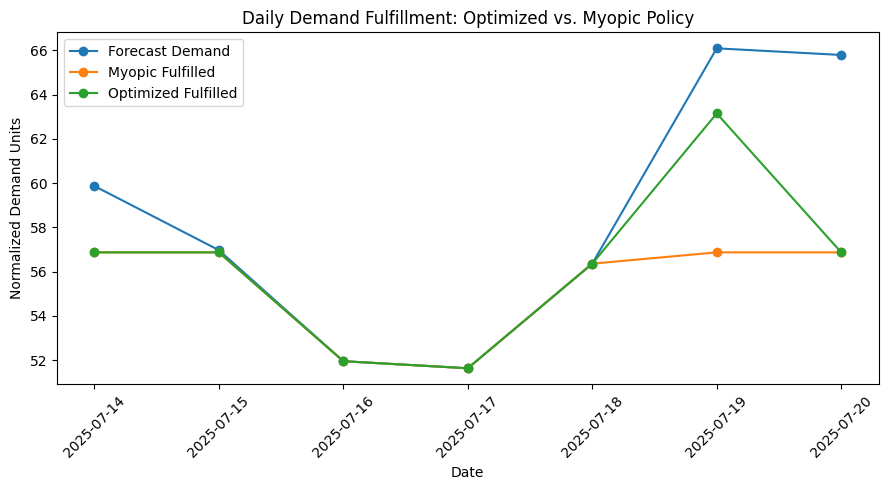

In [54]:
FIGURE_DIR = (
    ROOT
    / "figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

plt.figure(figsize=(9, 5))

plt.plot(
    benchmark_daily["dt"],
    benchmark_daily["forecast_demand"],
    marker="o",
    label="Forecast Demand",
)

plt.plot(
    benchmark_daily["dt"],
    benchmark_daily["myopic_fulfilled"],
    marker="o",
    label="Myopic Fulfilled",
)

plt.plot(
    benchmark_daily["dt"],
    benchmark_daily["optimized_fulfilled"],
    marker="o",
    label="Optimized Fulfilled",
)

plt.xlabel("Date")
plt.ylabel("Normalized Demand Units")
plt.title(
    "Daily Demand Fulfillment: "
    "Optimized vs. Myopic Policy"
)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "daily_fulfillment_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

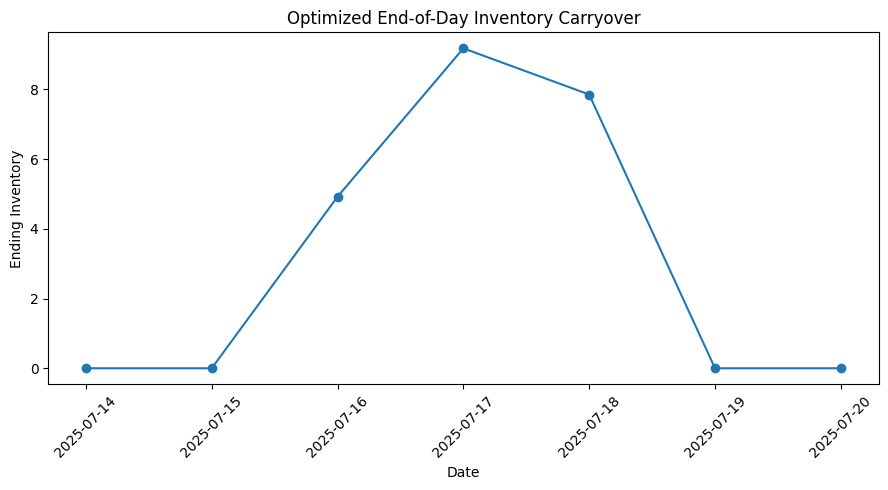

In [55]:
plt.figure(figsize=(9, 5))

plt.plot(
    final_daily_plan["dt"],
    final_daily_plan[
        "ending_inventory"
    ],
    marker="o",
)

plt.xlabel("Date")
plt.ylabel("Ending Inventory")
plt.title(
    "Optimized End-of-Day "
    "Inventory Carryover"
)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "inventory_carryover.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

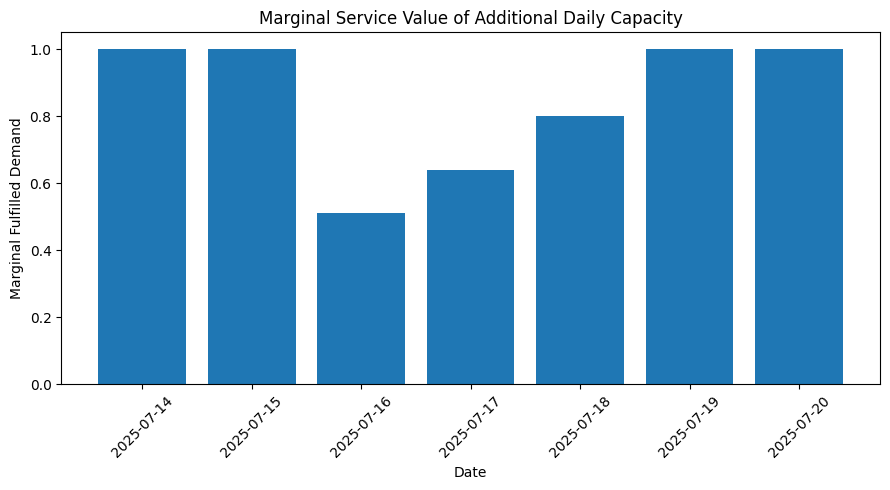

In [56]:
plt.figure(figsize=(9, 5))

plt.bar(
    capacity_duals["dt"],
    capacity_duals[
        "service_shadow_value"
    ],
)

plt.xlabel("Date")
plt.ylabel(
    "Marginal Fulfilled Demand"
)
plt.title(
    "Marginal Service Value of "
    "Additional Daily Capacity"
)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR
    / "capacity_shadow_values.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## 12. Optimization Summary

Under the base planning scenario, the maximum-service model fulfills
approximately 96.34% of the seven-day forecast demand. A second
lexicographic max-min stage eliminates arbitrary cross-product service
disparities, raising the minimum weekly product fill rate from 83.24% in the
unrestricted service optimum to 96.34% without sacrificing aggregate service.

A candidate third-stage inventory-minimization tie-breaker was also examined.
It did not reduce aggregate carried inventory because daily replenishment
capacity was binding throughout the base horizon, total replenishment was
fixed, and terminal inventory was zero. It was therefore omitted from the
final decision rule.

The optimized plan uses lower-demand days to build inventory ahead of the
July 19 demand peak. Relative to a proportional same-day replenishment policy,
multi-period planning fulfills 6.28 additional normalized demand units and
reduces unmet demand by approximately 29.6%.

Local capacity shadow values range from 0.512 to 1.000 normalized
fulfilled-demand units per additional unit of daily replenishment capacity.
The intermediate shadow values correspond directly to the assumed 0.80
inventory carryover factor and are reproduced by finite-difference
perturbations.

Sensitivity analysis shows that service improves with both replenishment
capacity and inventory carryover while capacity remains scarce. Once the
75th-percentile capacity scenario is reached, the fixed seven-day demand
forecast can be fully served under all tested carryover assumptions.

All numerical results represent model-implied planning outcomes under stated
normalized scenarios rather than observed retailer costs, profits, capacities,
or deployed operational decisions.